In [87]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd())
print(path)
sys.path.insert(1, path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/joaquin/Documents/GitHub/skforecast/dev/arima


In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from arima import ARIMA as ARIMACUSTOM
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from aeon.datasets import load_airline
from statsforecast.models import ARIMA
from skforecast.datasets import fetch_dataset
import warnings
import time

In [89]:
# Data set 1: Fuel Consumption
data = fetch_dataset(name='fuel_consumption', raw=True, verbose=False)
# data = data[['Fecha', 'Gasolinas']]
# data = data.rename(columns={'Fecha':'date', 'Gasolinas':'litters'})
# data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
# data = data.set_index('date')
# data = data.loc[:'1990-01-01 00:00:00']
# data = data.asfreq('MS')
# data = data[['litters']]
# data = data.rename(columns={'litters': 'y'})
# data['month'] = data.index.month.astype('float')
# end_train = '1980-01-01 23:59:59'
# data_train = data.loc[:end_train]
# data_test  = data.loc[end_train:]
# print(f"Train samples: {len(data_train)}")
# print(f"Test samples:  {len(data_test)}")

# Data set 2: Airline Passengers
# data = load_airline(return_array=False).to_frame(name='y')
# data = data.asfreq('M')
# data['month'] = data.index.month.astype('float')
# end_train = '1957-12-01 23:59:59'
# data_train = data.loc[:end_train]
# data_test  = data.loc[end_train:]
# print(f"Train samples: {len(data_train)}")
# print(f"Test samples:  {len(data_test)}")

# Data set 3: Website Visits
data = fetch_dataset(name="website_visits", raw=True, verbose=False)
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%y')
data = data.set_index('date')
data = data.asfreq('1D')
data = data.sort_index()
data = data.rename(columns={'users': 'y'})
data['month'] = data.index.month.astype('float')
end_train = '2021-06-30 23:59:00'
data_train = data.loc[: end_train, :]
data_test  = data.loc[end_train:, :]

data

,y,month
date,,
2020-07-01,2324,7.0
2020-07-02,2201,7.0
2020-07-03,2146,7.0
2020-07-04,1666,7.0
2020-07-05,1433,7.0
...,...,...
2021-08-21,1546,8.0
2021-08-22,1393,8.0
2021-08-23,2371,8.0


In [90]:
# data = sm.datasets.get_rdataset("AirPassengers").data
# data = data[['value']]
# data = data.rename(columns={'value': 'y'})
# data_train = data.iloc[:120]
# data_test = data.iloc[120:]


# data = sm.datasets.sunspots.load_pandas().data
# data = data.rename(columns={'SUNACTIVITY': 'y'})
# data_train = data.iloc[:250]
# data_test = data.iloc[250:]

In [91]:
order = (12, 1, 2)
trend = None  # 'n', 'c', 't', 'ct'
exog = data_train[['month']]
exog_test = data_test[['month']]


print("Fitting Statsmodels SARIMAX...")
warnings.filterwarnings("ignore") # Suppress convergence warnings for cleaner output
start_time = time.time()
sm_model = SARIMAX(endog=data_train['y'],
                   exog=exog,
                   order=order, 
                   trend=trend
                ) 
sm_res = sm_model.fit(disp=0)
sm_pred = sm_res.get_forecast(steps=len(data_test), exog=exog_test).predicted_mean
print(f"Statsmodels fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{sm_res.params}\n")

print("Fitting Custom arima...")
start_time = time.time()
arimax_model = ARIMACUSTOM(order=order)
arimax_model.fit(y=data_train['y'], exog=exog)
arimax_pred_values = arimax_model.predict(steps=len(data_test), exog=exog_test)
arimax_pred = pd.Series(arimax_pred_values, index=data_test.index)
print(f"Custom arima fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{arimax_model.ar_coef_} {arimax_model.ma_coef_} {arimax_model.intercept_}\n")

print("Fitting StatsForecast ARIMA...")
start_time = time.time()
sf_model = ARIMA(order=order)
sf_model.fit(y=data_train['y'], X=exog.to_numpy() if exog is not None else None)
sf_pred_values = sf_model.predict(h=len(data_test), X=exog_test.to_numpy() if exog_test is not None else None)
sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
print(f"StatsForecast ARIMA fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{sf_model.model_['coef']}\n")

Fitting Statsmodels SARIMAX...
Statsmodels fitting time: 6.24 seconds

Model parameters:
month        17.784389
ar.L1         0.321647
ar.L2        -0.846312
ar.L3         0.081469
ar.L4        -0.261950
ar.L5         0.003722
ar.L6        -0.084797
ar.L7         0.579062
ar.L8        -0.321861
ar.L9         0.469984
ar.L10       -0.201006
ar.L11        0.020861
ar.L12       -0.234163
ma.L1        -0.373937
ma.L2         0.617463
sigma2    72894.557544
dtype: float64

Fitting Custom arima...
Statsmodels fitting time: 6.24 seconds

Model parameters:
month        17.784389
ar.L1         0.321647
ar.L2        -0.846312
ar.L3         0.081469
ar.L4        -0.261950
ar.L5         0.003722
ar.L6        -0.084797
ar.L7         0.579062
ar.L8        -0.321861
ar.L9         0.469984
ar.L10       -0.201006
ar.L11        0.020861
ar.L12       -0.234163
ma.L1        -0.373937
ma.L2         0.617463
sigma2    72894.557544
dtype: float64

Fitting Custom arima...
Custom arima fitting time: 0.22 secon

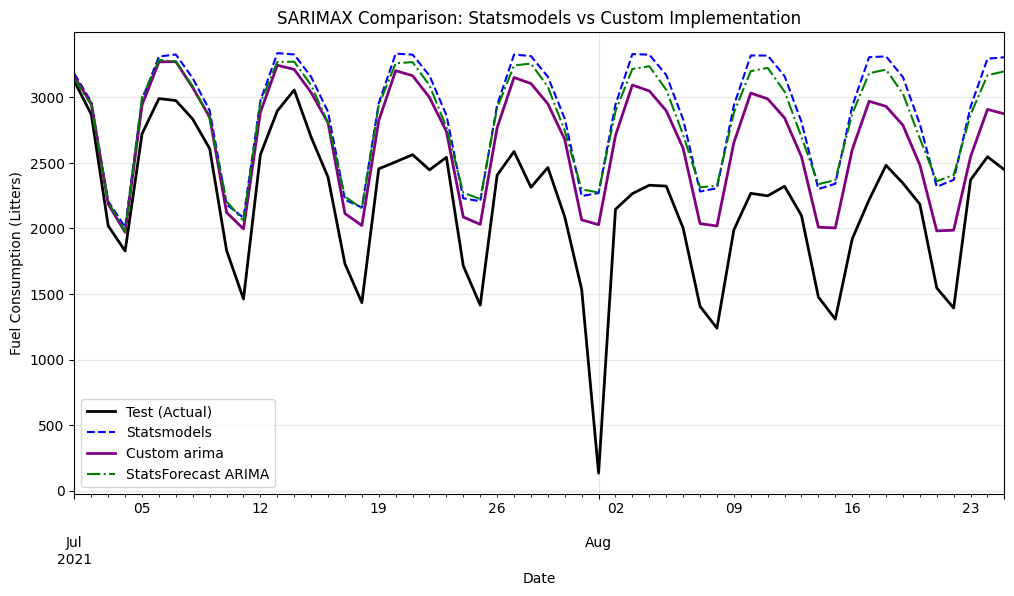

,MAE
Model,
Custom arima,489.447634
StatsForecast ARIMA,640.681356
Statsmodels SARIMAX,688.735021


In [92]:
# Visualization & Comparison
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
# data_train.loc[:end_train, 'y'].plot(label='Train (Last 5 Years)', color='gray', alpha=0.5, ax=ax)
data_test['y'].plot(label='Test (Actual)', color='black', linewidth=2, ax=ax)
sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax)
arimax_pred.plot(label='Custom arima', linestyle='-', color='purple', linewidth=2, ax=ax)
sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax)
plt.title('SARIMAX Comparison: Statsmodels vs Custom Implementation')
plt.xlabel('Date')
plt.ylabel('Fuel Consumption (Litters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Numerical Error Comparison
# -----------------------------------------------------------------------------
mae_sm = (data_test['y'] - sm_pred).abs().mean()
mae_sf = (data_test['y'] - sf_pred).abs().mean()
mae_arimax = (data_test['y'] - arimax_pred).abs().mean()

pd.DataFrame({
    'Model': ['Statsmodels SARIMAX', 'StatsForecast ARIMA', 'Custom arima'],
    'MAE': [mae_sm, mae_sf, mae_arimax]
}).set_index('Model').sort_values(by='MAE')

In [93]:
pd.DataFrame({
    'Statsmodels': sm_pred,
    'Custom arima': arimax_pred,
    'StatsForecast ARIMA': sf_pred
})

,Statsmodels,Custom arima,StatsForecast ARIMA
2021-07-01,3180.439951,3156.751166,3141.349190
2021-07-02,2965.082963,2953.071828,2940.343575
2021-07-03,2207.528367,2185.843689,2203.825805
2021-07-04,2009.269656,1970.975678,1975.985679
2021-07-05,2984.924885,2941.910648,2998.910946
2021-07-06,3311.883822,3271.097566,3286.788341
2021-07-07,3327.492804,3272.958675,3272.795708
2021-07-08,3146.229760,3074.215810,3084.558556
2021-07-09,2899.942007,2849.979466,2838.159399
2021-07-10,2183.138272,2121.737630,2205.905285


# Comprehensive Parameter Testing

Let's test various ARIMA configurations to validate the implementation across different model complexities.

In [94]:
# Test different ARIMA configurations
import numpy as np

test_orders = [
    (1, 0, 0),   # Simple AR(1) - no differencing
    (0, 0, 1),   # Simple MA(1) - no differencing
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 0),   # AR(2) with differencing
    (0, 1, 2),   # MA(2) with differencing
    (1, 1, 1),   # ARMA(1,1) with differencing
    (2, 1, 1),   # ARMA(2,1) with differencing
    (3, 1, 1),   # Current best (ARMA(3,1) with differencing)
    (2, 1, 2),   # ARMA(2,2) with differencing
    (1, 2, 1),   # ARMA(1,1) with second-order differencing
]

results = []

for order in test_orders:
    print(f"\nTesting ARIMA{order}...")
    
    try:
        # Custom ARIMA
        start_time = time.time()
        custom_model = ARIMACUSTOM(order=order)
        custom_model.fit(y=data_train['y'])
        custom_pred = custom_model.predict(steps=len(data_test))
        custom_time = time.time() - start_time
        custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
        
        # Statsmodels SARIMAX
        start_time = time.time()
        sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
        sm_res = sm_model.fit(disp=0)
        sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean
        sm_time = time.time() - start_time
        sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
        
        # StatsForecast ARIMA
        start_time = time.time()
        sf_model = ARIMA(order=order)
        sf_model.fit(y=data_train['y'])
        sf_pred_values = sf_model.predict(h=len(data_test))
        sf_time = time.time() - start_time
        sf_mae = np.abs(data_test['y'].values - sf_pred_values['mean']).mean()
        
        # Calculate differences
        diff_sm = np.abs(custom_pred - sm_pred.values).mean()
        diff_sf = np.abs(custom_pred - sf_pred_values['mean']).mean()
        
        results.append({
            'Order': f"ARIMA{order}",
            'Custom MAE': f"{custom_mae:.0f}",
            'SM MAE': f"{sm_mae:.0f}",
            'SF MAE': f"{sf_mae:.0f}",
            'Diff vs SM': f"{diff_sm:.0f}",
            'Diff vs SF': f"{diff_sf:.0f}",
            'Custom Time': f"{custom_time:.3f}s",
            'SM Time': f"{sm_time:.3f}s",
            'SF Time': f"{sf_time:.3f}s",
        })
        
        print(f"  ✓ Custom MAE: {custom_mae:.0f} | SM MAE: {sm_mae:.0f} | SF MAE: {sf_mae:.0f}")
        print(f"    Pred diff vs SM: {diff_sm:.0f} | vs SF: {diff_sf:.0f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}")
        results.append({
            'Order': f"ARIMA{order}",
            'Custom MAE': 'ERROR',
            'SM MAE': '-',
            'SF MAE': '-',
            'Diff vs SM': '-',
            'Diff vs SF': '-',
            'Custom Time': '-',
            'SM Time': '-',
            'SF Time': '-',
        })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON RESULTS")
print("="*100)
results_df


Testing ARIMA(1, 0, 0)...
  ✓ Custom MAE: 771 | SM MAE: 499 | SF MAE: 769
    Pred diff vs SM: 784 | vs SF: 2

Testing ARIMA(0, 0, 1)...
  ✓ Custom MAE: 725 | SM MAE: 2125 | SF MAE: 725
    Pred diff vs SM: 2835 | vs SF: 0

Testing ARIMA(1, 0, 1)...
  ✓ Custom MAE: 725 | SM MAE: 2125 | SF MAE: 725
    Pred diff vs SM: 2835 | vs SF: 0

Testing ARIMA(1, 0, 1)...
  ✓ Custom MAE: 748 | SM MAE: 860 | SF MAE: 748
    Pred diff vs SM: 1360 | vs SF: 1

Testing ARIMA(2, 1, 0)...
  ✓ Custom MAE: 1132 | SM MAE: 1133 | SF MAE: 1132
    Pred diff vs SM: 0 | vs SF: 0

Testing ARIMA(0, 1, 2)...
  ✓ Custom MAE: 748 | SM MAE: 860 | SF MAE: 748
    Pred diff vs SM: 1360 | vs SF: 1

Testing ARIMA(2, 1, 0)...
  ✓ Custom MAE: 1132 | SM MAE: 1133 | SF MAE: 1132
    Pred diff vs SM: 0 | vs SF: 0

Testing ARIMA(0, 1, 2)...
  ✓ Custom MAE: 1041 | SM MAE: 1033 | SF MAE: 1032
    Pred diff vs SM: 9 | vs SF: 9

Testing ARIMA(1, 1, 1)...
  ✓ Custom MAE: 1277 | SM MAE: 1278 | SF MAE: 1278
    Pred diff vs SM: 1 | 

,Order,Custom MAE,SM MAE,SF MAE,Diff vs SM,Diff vs SF,Custom Time,SM Time,SF Time
0,"ARIMA(1, 0, 0)",771,499,769,784,2,0.001s,0.019s,0.058s
1,"ARIMA(0, 0, 1)",725,2125,725,2835,0,0.002s,0.113s,0.134s
2,"ARIMA(1, 0, 1)",748,860,748,1360,1,0.001s,0.134s,0.131s
3,"ARIMA(2, 1, 0)",1132,1133,1132,0,0,0.001s,0.022s,0.017s
4,"ARIMA(0, 1, 2)",1041,1033,1032,9,9,0.002s,0.131s,0.034s
5,"ARIMA(1, 1, 1)",1277,1278,1278,1,1,0.002s,0.114s,0.055s
6,"ARIMA(2, 1, 1)",918,911,910,7,7,0.003s,0.141s,0.041s
7,"ARIMA(3, 1, 1)",898,894,892,4,6,0.003s,0.318s,0.100s
8,"ARIMA(2, 1, 2)",816,720,715,135,143,0.010s,0.636s,0.105s
9,"ARIMA(1, 2, 1)",1864,1330,1279,534,586,0.001s,0.143s,0.067s


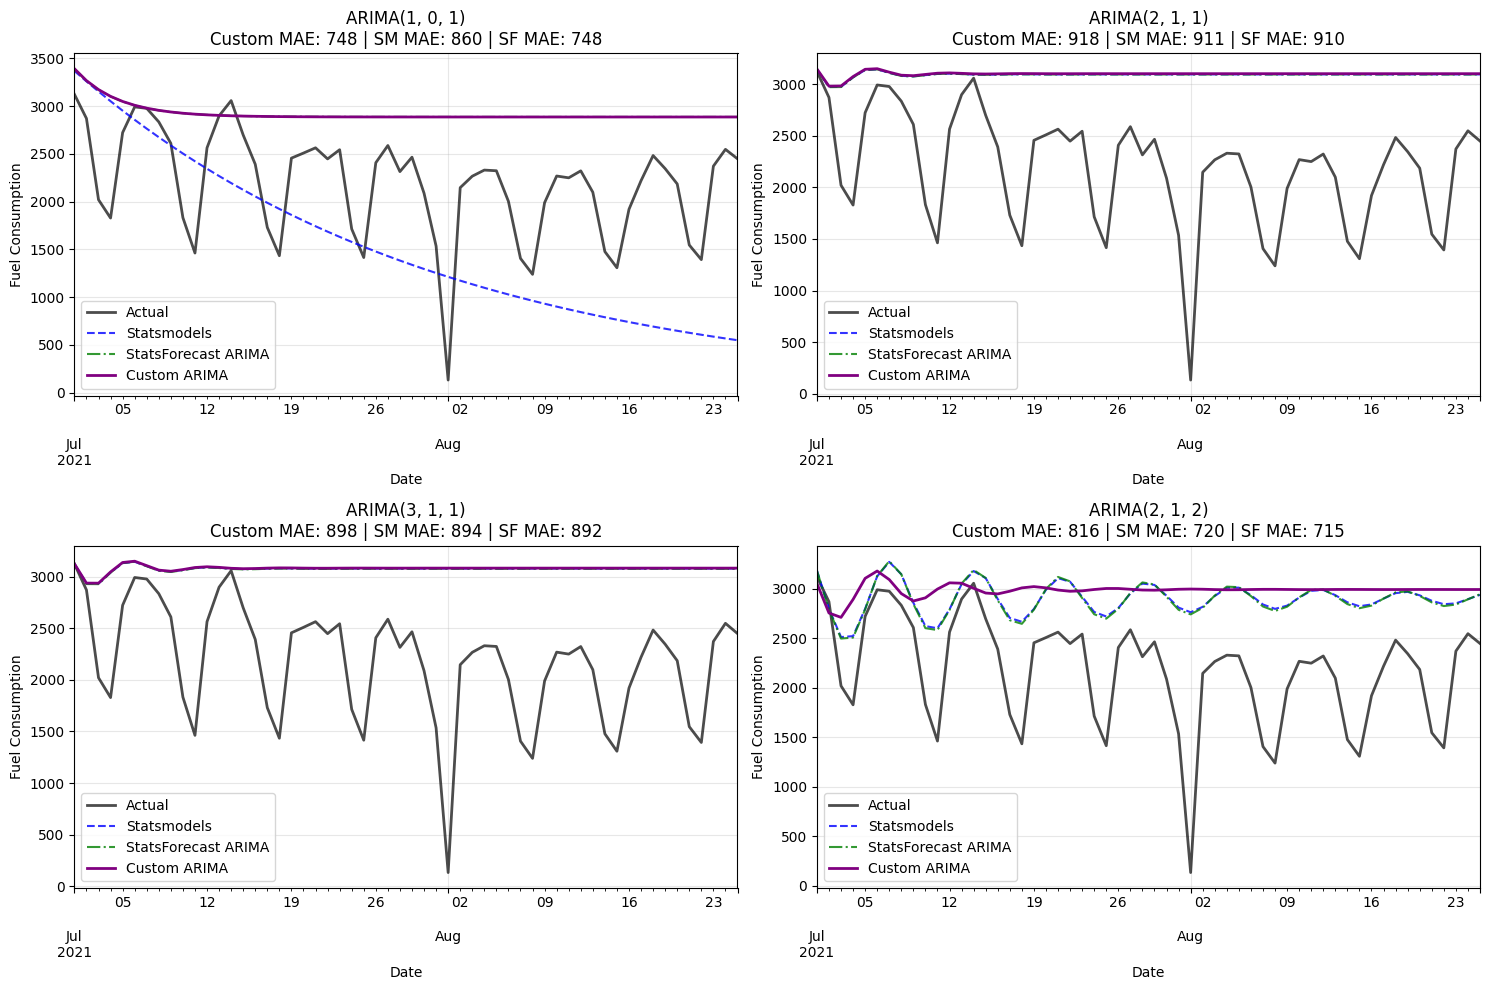

In [95]:
# Visualize best performing models
best_models = [
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 1),   # ARMA(2,1) with differencing  
    (3, 1, 1),   # ARMA(3,1) with differencing
    (2, 1, 2),   # ARMA(2,2) with differencing
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, order in enumerate(best_models):
    ax = axes[idx]
    
    # Fit models
    custom_model = ARIMACUSTOM(order=order)
    custom_model.fit(y=data_train['y'])
    custom_pred = custom_model.predict(steps=len(data_test))
    
    sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
    sm_res = sm_model.fit(disp=0)
    sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean

    sf_model = ARIMA(order=order)
    sf_model.fit(y=data_train['y'])
    sf_pred_values = sf_model.predict(h=len(data_test))
    sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
    
    # Plot
    data_test['y'].plot(label='Actual', color='black', linewidth=2, ax=ax, alpha=0.7)
    sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax, alpha=0.8)
    sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax, alpha=0.8)
    pd.Series(custom_pred, index=data_test.index).plot(
        label='Custom ARIMA', linestyle='-', color='purple', linewidth=2, ax=ax
    )
    
    # Calculate errors
    custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
    sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
    sf_mae = np.abs(data_test['y'].values - sf_pred.values).mean()
    
    ax.set_title(f'ARIMA{order}\nCustom MAE: {custom_mae:.0f} | SM MAE: {sm_mae:.0f} | SF MAE: {sf_mae:.0f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Fuel Consumption')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()